## #01. 준비작업 

### 1. 라이브러리 참조 

In [34]:
# 라이브러리 기본 참조 
from jussam import load_data
from helpers import *
from pandas import DataFrame, melt

import seaborn as sb
import numpy as np

# 결과 검정을 위한 참조 
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, probplot, shapiro, kstest
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

### 2. 데이터 가져오기 

In [35]:
origin = load_data('cars')
origin.head()

📚 자동차의 속도(speed)에 따른 제동거리(dist) 조사 데이터 (출처: R 기본 데이터)


,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


### 3. 단순선형회귀 

In [36]:
fit = my_ols.fit_model(origin, y='dist')
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           1.49e-12
Time:                        18:05:41   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.5791      6.758     -2.601      0.012     -31.168      -3.990
speed          3.9324      0.416      9.464      0.000       3.097       4.768
==============================================================================
Omnibus:                        8.975   Durbin-Watson:                   1.676
Prob(Omnibus):                  0.011   Jarque-Bera (JB):                8.189
Skew:                           0.885   Prob(JB):                       0.0167
Kurtosis:                       3.893   Cond. No.                         50.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## #02. 가정 검정을 위한 준비 

### 1. 예측값을 직접 구하기 

In [37]:
y_pred = my_ols.predict(fit, origin[['speed']])
y_pred.head()

,pred
0,-1.849
1,-1.849
2,9.948
3,9.948
4,13.880


### 2. 회귀분석 결과 객체에 내장되어 있는 예측값 

In [38]:
y_pred_values = fit.fittedvalues    # 모델에 내장된 예측값 
y_pred_values.head()                # 상위 5건 확인 

0   -1.849
1   -1.849
2    9.948
3    9.948
4   13.880
dtype: float64

### 3. 잔차 직접 구하기 

In [39]:
# 잔차 = 실제 종속변수 - 예측값 
# residual = origin['dist'] - y_pred['pred']

# 위 코드와 아래 코드의 결과는 동일함 
residual = origin['dist'] - y_pred_values

# 상위 5건 확인 
residual.head()

0    3.849
1   11.849
2   -5.948
3   12.052
4    2.120
dtype: float64

### 4. 회귀분석 결과에 내장되어 있는 잔차 가져오기 

In [40]:
# 직전 코드와 동일한 결과이다. 
residual_values = fit.resid     # 내장되어 있는 잔차
residual_values.head()          # 상위 5건 확인  

0    3.849
1   11.849
2   -5.948
3   12.052
4    2.120
dtype: float64

### 5. 잔차를 분석 데이터에 결합 

In [41]:
ols_df = origin.copy()              # 원본 데이터 복사 
ols_df['y_pred'] = fit.fittedvalues # 복사한 데이터에 예측값 추가 
ols_df['resid'] = fit.resid         # 복사한 데이터에 잔차 추가 
ols_df.head()                       # 상위 5건 확인 

,speed,dist,y_pred,resid
0,4,2,-1.849,3.849
1,4,10,-1.849,11.849
2,7,4,9.948,-5.948
3,7,22,9.948,12.052
4,8,16,13.880,2.120


## #03. 선형성 검정 

### 1. 시각화를 통한 검정 

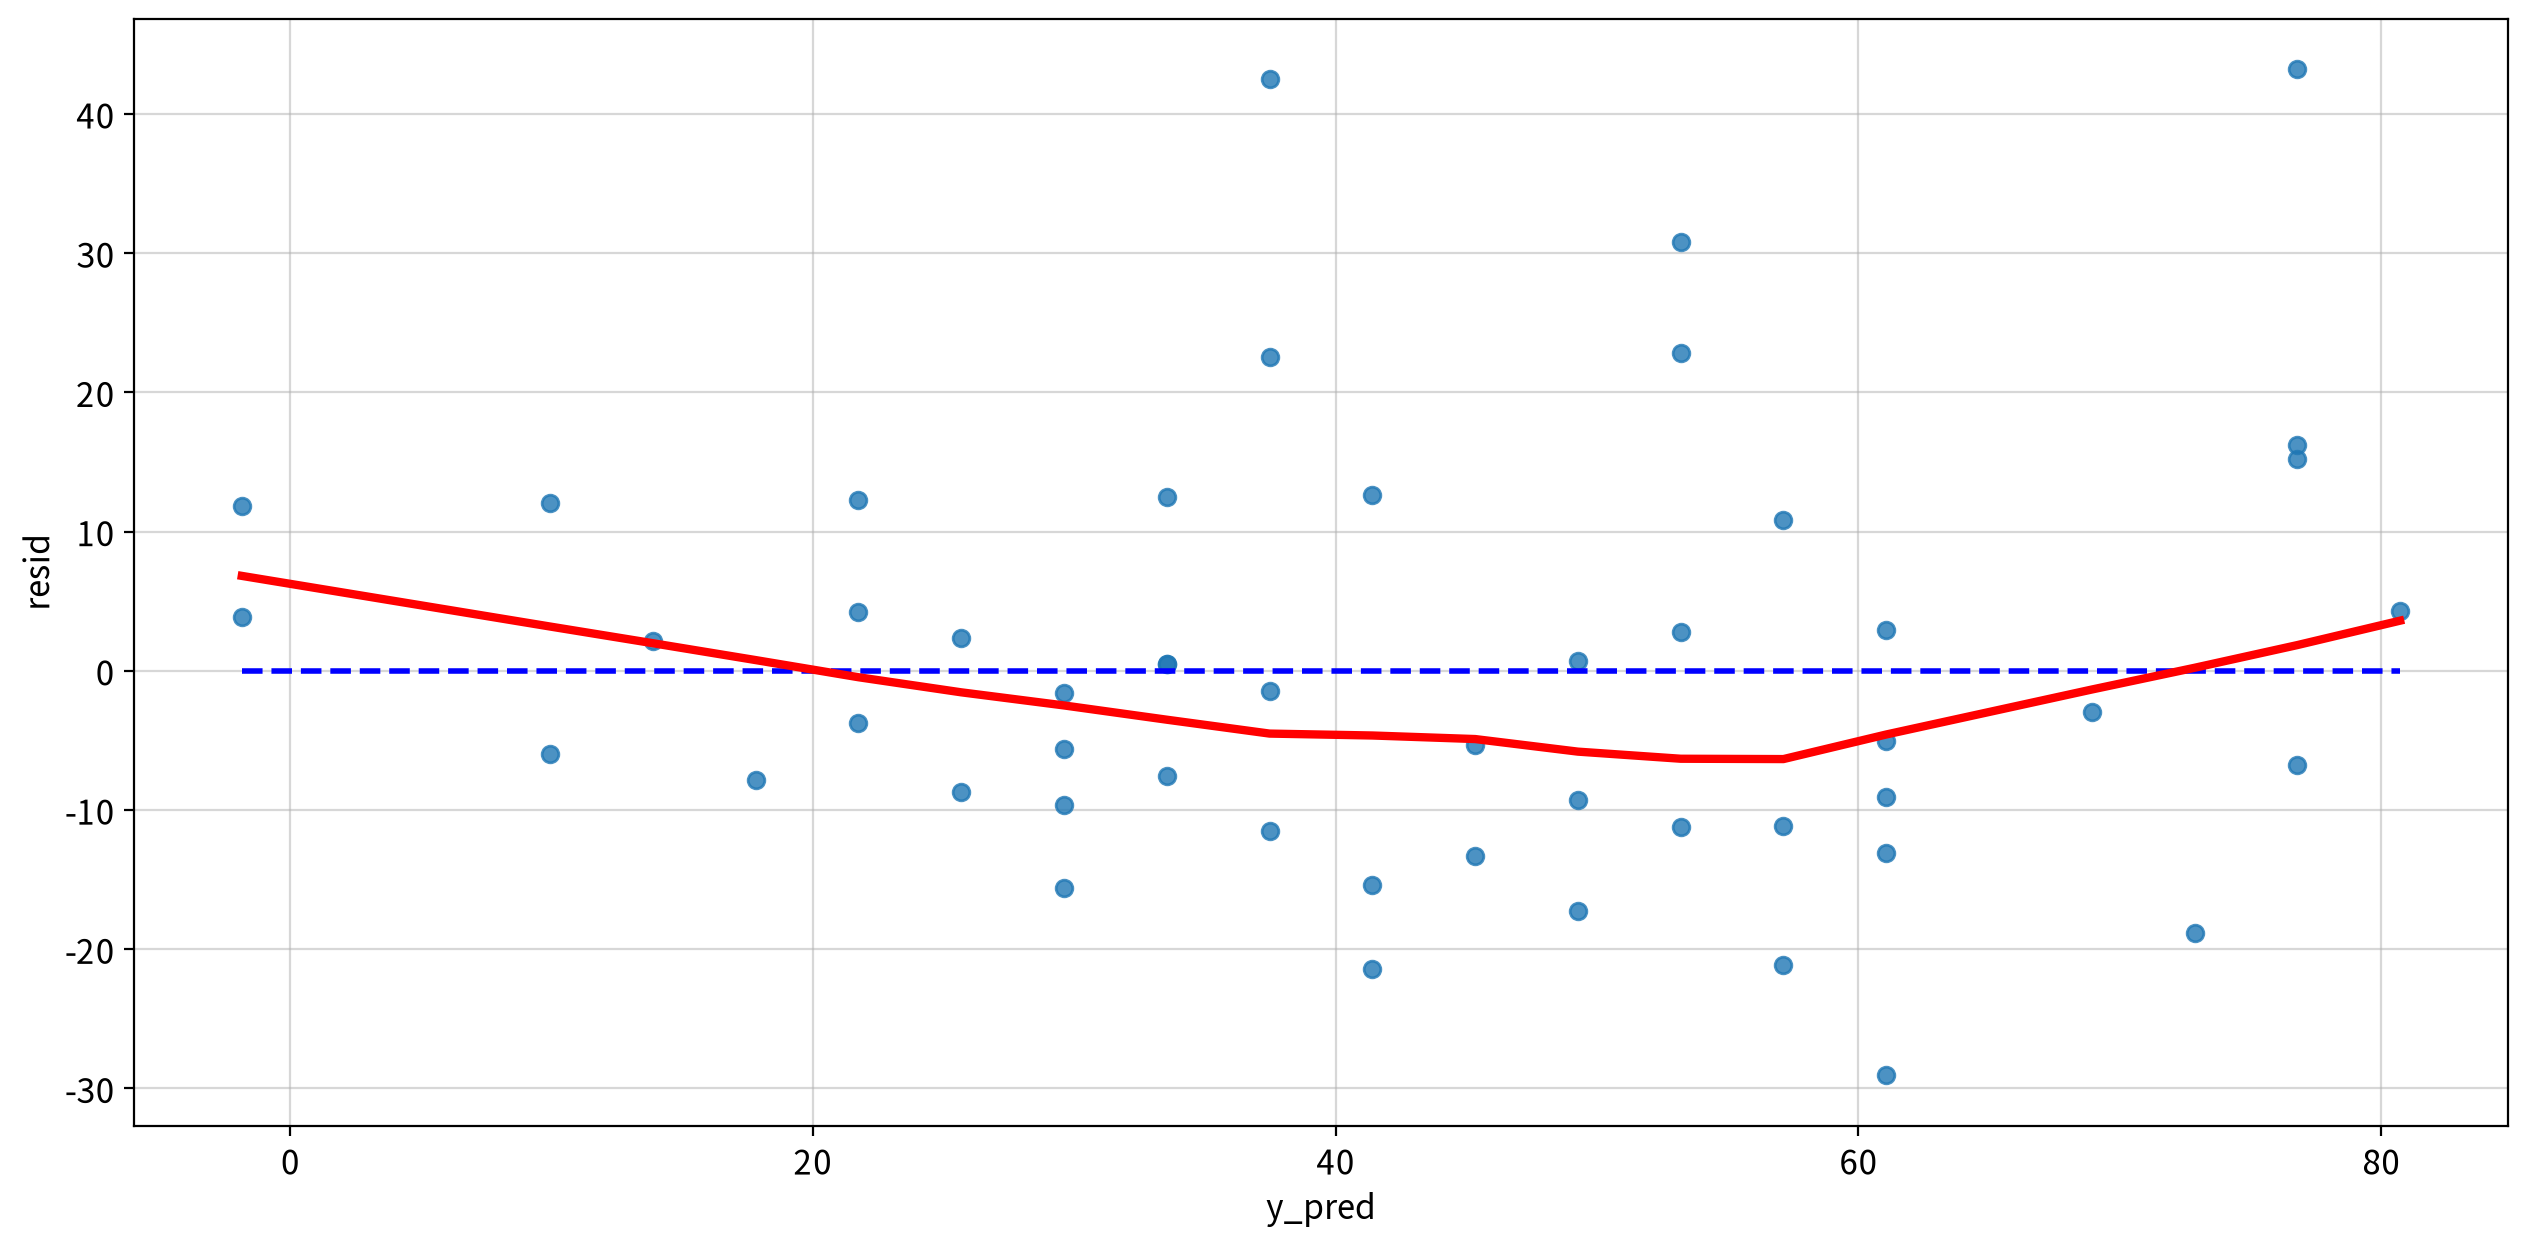

In [42]:
xmin = ols_df['y_pred'].min()   # 예측값(y_pred)의 최솟값 -> 기준선을 그릴 x축 시작점
xmax = ols_df['y_pred'].max()   # 예측값(y_pred)의 최댓값 -> 기준선을 그릴 x축 끝점 
xrange = [xmin, xmax]           # 기준선의 x좌표 범위 (시작점 ~ 끝점 )
yrange = [0, 0]                 # 기준선의 y좌표 (잔차=0을 나타내는 수평선이므로 양 끝 모두 0)

fig, ax = my_plot.init()        # 그래프 (figure)와 축(axes) 객체 생성 

# 잔차 = 0 기준선을 파란 점선으로 그리기 (잔차가 이 선 근처에 고르게 있어야 선형성 만족) 
my_plot.lineplot(x=xrange, y=yrange, color='blue', linestyle='--', ax=ax)

# 예측값 대비 잔차 산점도 + lowess(비선형) 추세선(빨강) -> 곡선으로 휘면 선형성 위배 신호 
sb.regplot(data=ols_df, x='y_pred', y='resid', lowess=True, line_kws={'color':'red'}, ax=ax)

my_plot.show()                  # 완성된 그래프 출력 

### 2. 통계량을 통한 검정 - Ramsey RESET Test 

In [43]:
reset_res = linear_reset(fit, power=2, use_f=True)
print(f'RESET 검정 결과 : F-statistic = {reset_res.fvalue:.4f}, p-value={reset_res.pvalue:.4f}')

RESET 검정 결과 : F-statistic = 2.2960, p-value=0.1364


## #04. 잔차의 정규성 검정 

### 1. Q-Q Plot(1) - 잔차의 z-score 구하기 

In [44]:
# 정규성은 '잔차(resid)'에 대한 가정이므로 잔차를 표준화(zscore)한다.
# (주의: 예측값 y_pred를 쓰면 안된다.
#        단순회귀에서 y_pred는 speed의 선형변환이라 잔차의 정규성과 무관)
ols_df['zscore'] = zscore(ols_df['resid'])
ols_df.head()     

,speed,dist,y_pred,resid,zscore
0,4,2,-1.849,3.849,0.255
1,4,10,-1.849,11.849,0.786
2,7,4,9.948,-5.948,-0.395
3,7,22,9.948,12.052,0.800
4,8,16,13.880,2.120,0.141


### 2. Q-Q Plot(2) Q-Q Plot의 좌표 구하기 

In [45]:
(x, y), _ = probplot(ols_df['zscore'])  # 그래프의 x, y 좌표를 반환

ols_df['qq_x'] = x      # Q-Q plot의 x좌표
ols_df['qq_y'] = y      # Q-Q plot의 y좌표

ols_df.head()           # 상위 5건 확인 

,speed,dist,y_pred,resid,zscore,qq_x,qq_y
0,4,2,-1.849,3.849,0.255,-2.204,-1.929
1,4,10,-1.849,11.849,0.786,-1.833,-1.421
2,7,4,9.948,-5.948,-0.395,-1.614,-1.403
3,7,22,9.948,12.052,0.800,-1.453,-1.252
4,8,16,13.880,2.120,0.141,-1.323,-1.146


### 2. Q-Q Plot(3) 시각화 

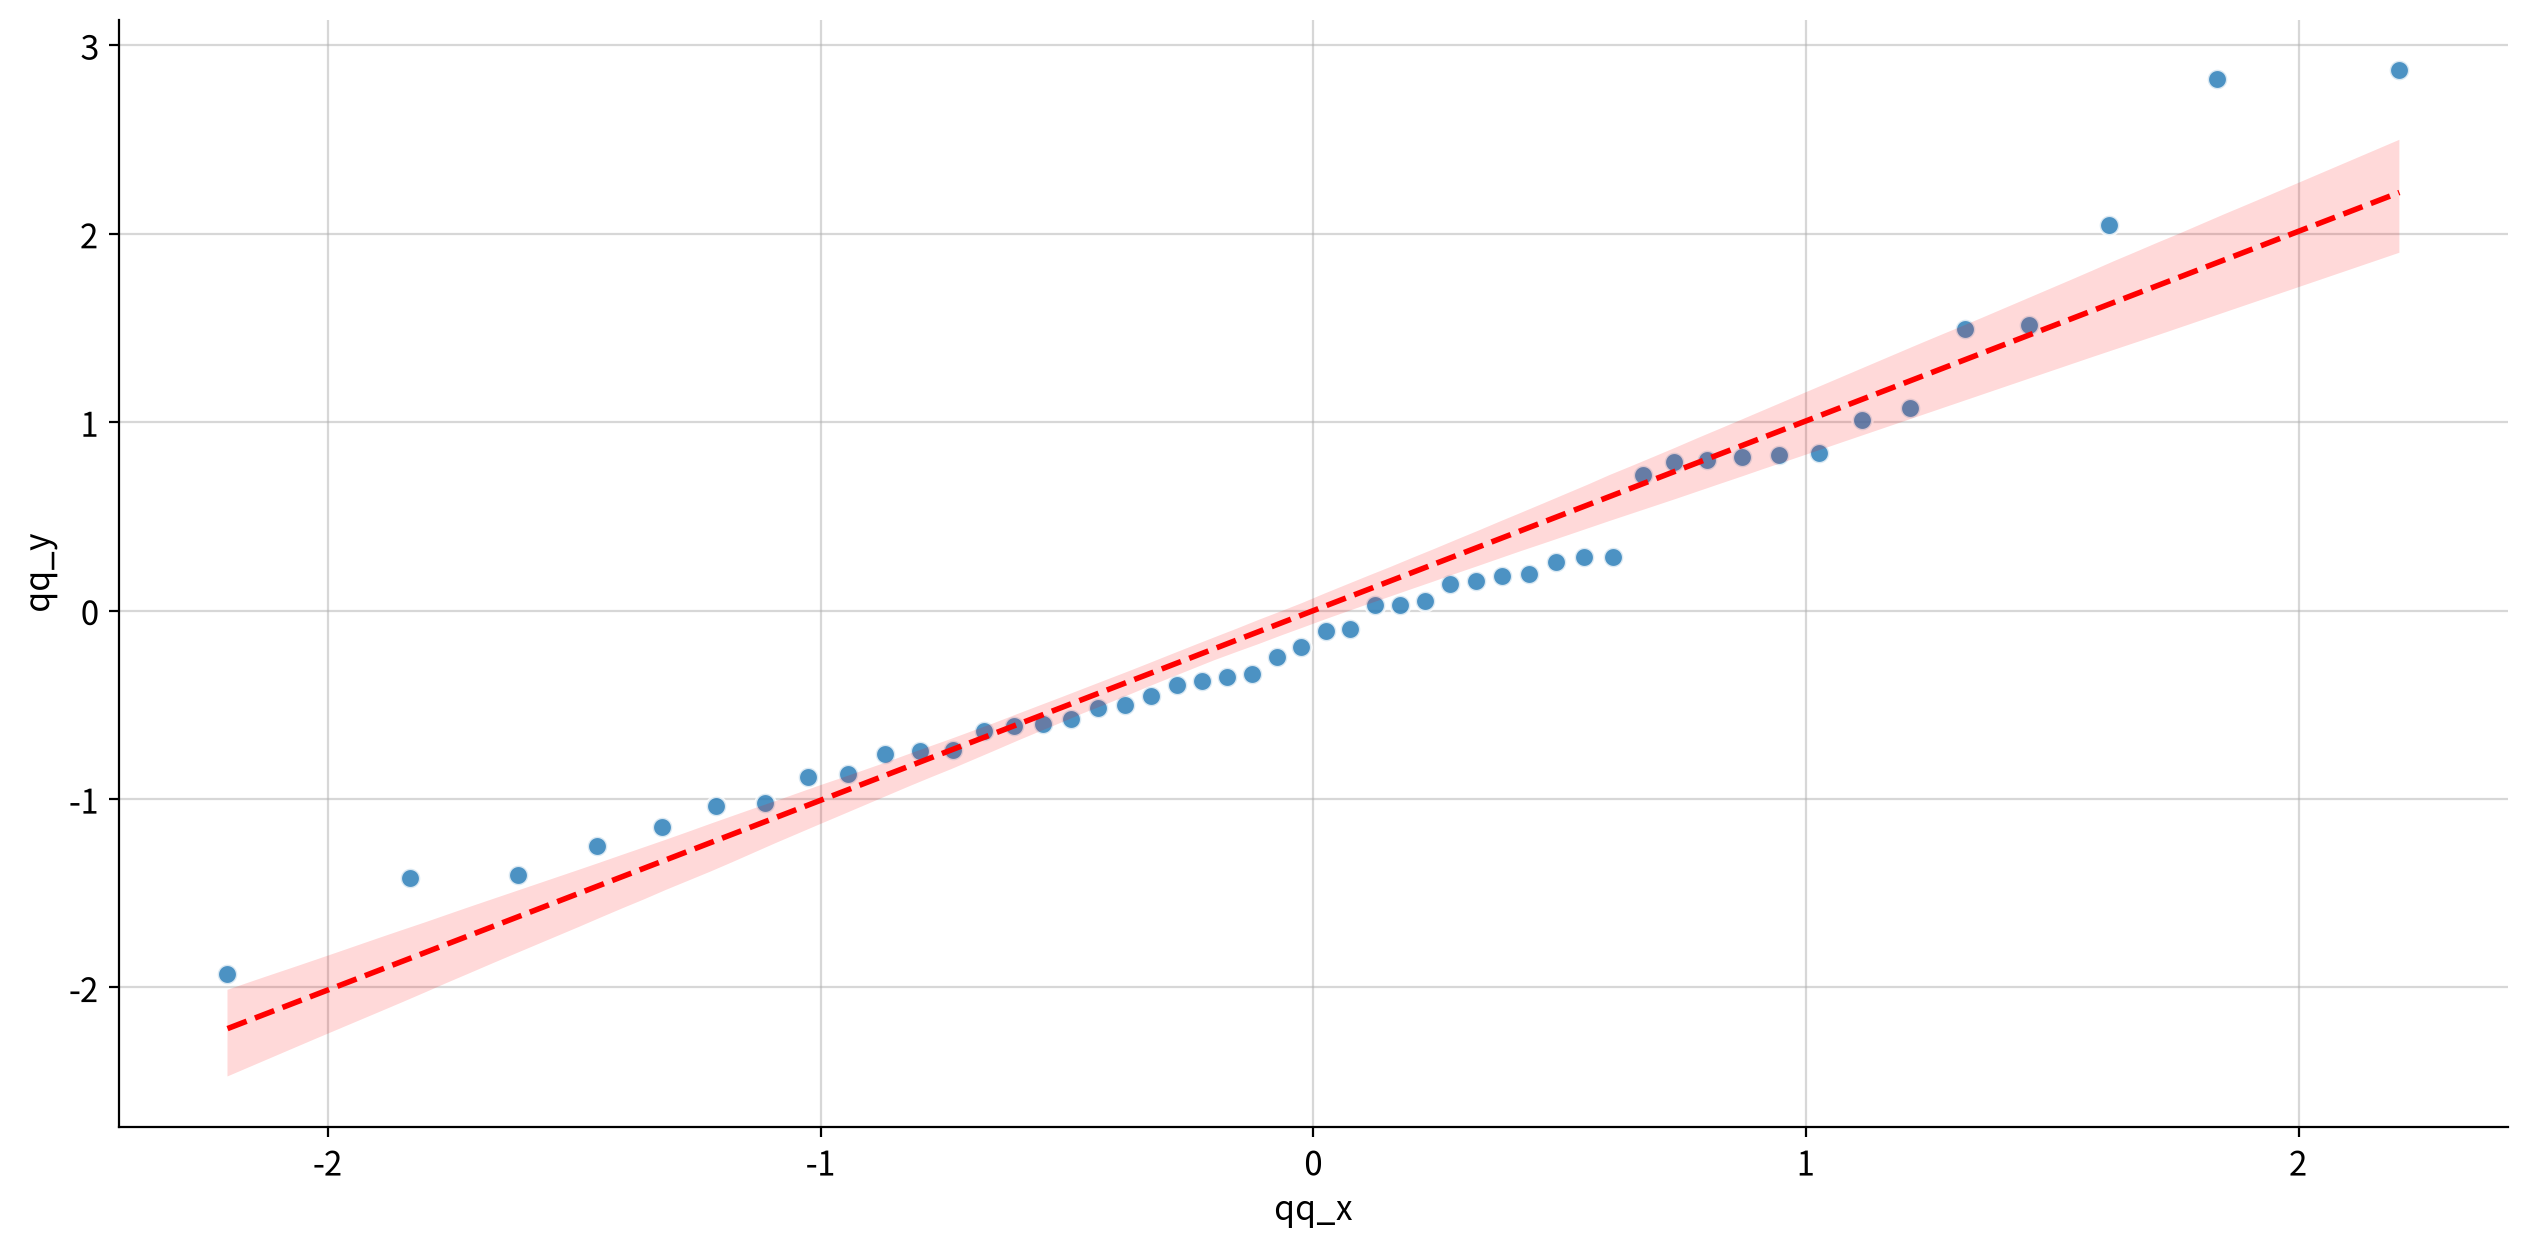

In [46]:
my_plot.lmplot(ols_df, x='qq_x', y='qq_y', linecolor='red', 
               linestyle="--")  

## #04. 잔차의 정규성 검정 

### 3. 루트MSE 구간별 비율 구하기 

In [47]:
MSE_sq = np.sqrt(fit.mse_resid) # 잔차 표준오차 
r = fit.resid       # 잔차 
n = r.count()       # 표본수 

# 잔차가 -루트MSE ~ +루트MSE 구간에 있는 경우의 비율 : 68% 이내여야 함 
r1 = r[ (r > -MSE_sq) & ( r < MSE_sq)].count() / r.count() *100

# 잔차가 -2/루트MSE ~ +2루트MSE 구간에 있는 경우의 비율 : 95% 이내여야 함
r2 = r[ (r > -2*MSE_sq) & (r < 3*MSE_sq)].count() / r.count() *100

# 잔차가 -3루트MSE ~ +3루트MSE 구간에 있는 경우의 비율 : 99.7% 이내여야 함 
r3 = r[ (r > -3*MSE_sq) & (r < 2*MSE_sq)].count() / r.count()*100

# 세 종류의 잔차 비율을 리스트로 묶기 
mse_r = [r1, r2, r3]

print(f"루트MSE = {MSE_sq:.2f}\n")
print(mse_r)

루트MSE = 15.38

[np.float64(74.0), np.float64(100.0), np.float64(94.0)]


### 4. 루트MSE구간 규칙을 통한 정규성 판정 

In [48]:
expected = [68, 95, 99.7]   # +-1, +-2, +-3 루트MSE 구간의 정규분포 기대 비율(%)
mse_judge = []              # 구간별 규칙 충족 여부 

for k, exp, actual in zip([1,2,3], expected, mse_r):
    pe = exp/100    # 기대 비율을 소수로 변환 
    se = np.sqrt(pe* (1-pe)/n)  # 기대 비율의 표준오차 
    lo = max(0, pe-2*se) *100   # 허용 범위 하한 (0과 계산값 중 큰 값: 0보다 작으면 0으로 처리 )
    hi = min(1, pe+2*se) *100   # 허용 범위 상한 (1과 계산값 중 작은 값: 1보다 크면 1로 처리)

    ok = lo <= actual <= hi     # 실제 비율이 허용 범위 안에 있는지 여부 확인

    print(f"+-{k}루트MSE 구간: 기대 {exp}%, 허용 구간 {lo:.0f}~{hi:.0f}%, "
          f"실제 {actual:.2f}% -> {'충족' if ok else '위배'}")
    
mse_rule = all(mse_judge) # 세 구간 모두 충족해야 규칙상 정규성 부합 
print(f"\n루트MSE 구간 규칙 판정 : {'정규성 부합' if mse_rule else '정규성 위배'}")

+-1루트MSE 구간: 기대 68%, 허용 구간 55~81%, 실제 74.00% -> 충족
+-2루트MSE 구간: 기대 95%, 허용 구간 89~100%, 실제 100.00% -> 충족
+-3루트MSE 구간: 기대 99.7%, 허용 구간 98~100%, 실제 94.00% -> 위배

루트MSE 구간 규칙 판정 : 정규성 부합


### 5. 잔차도 시각화 

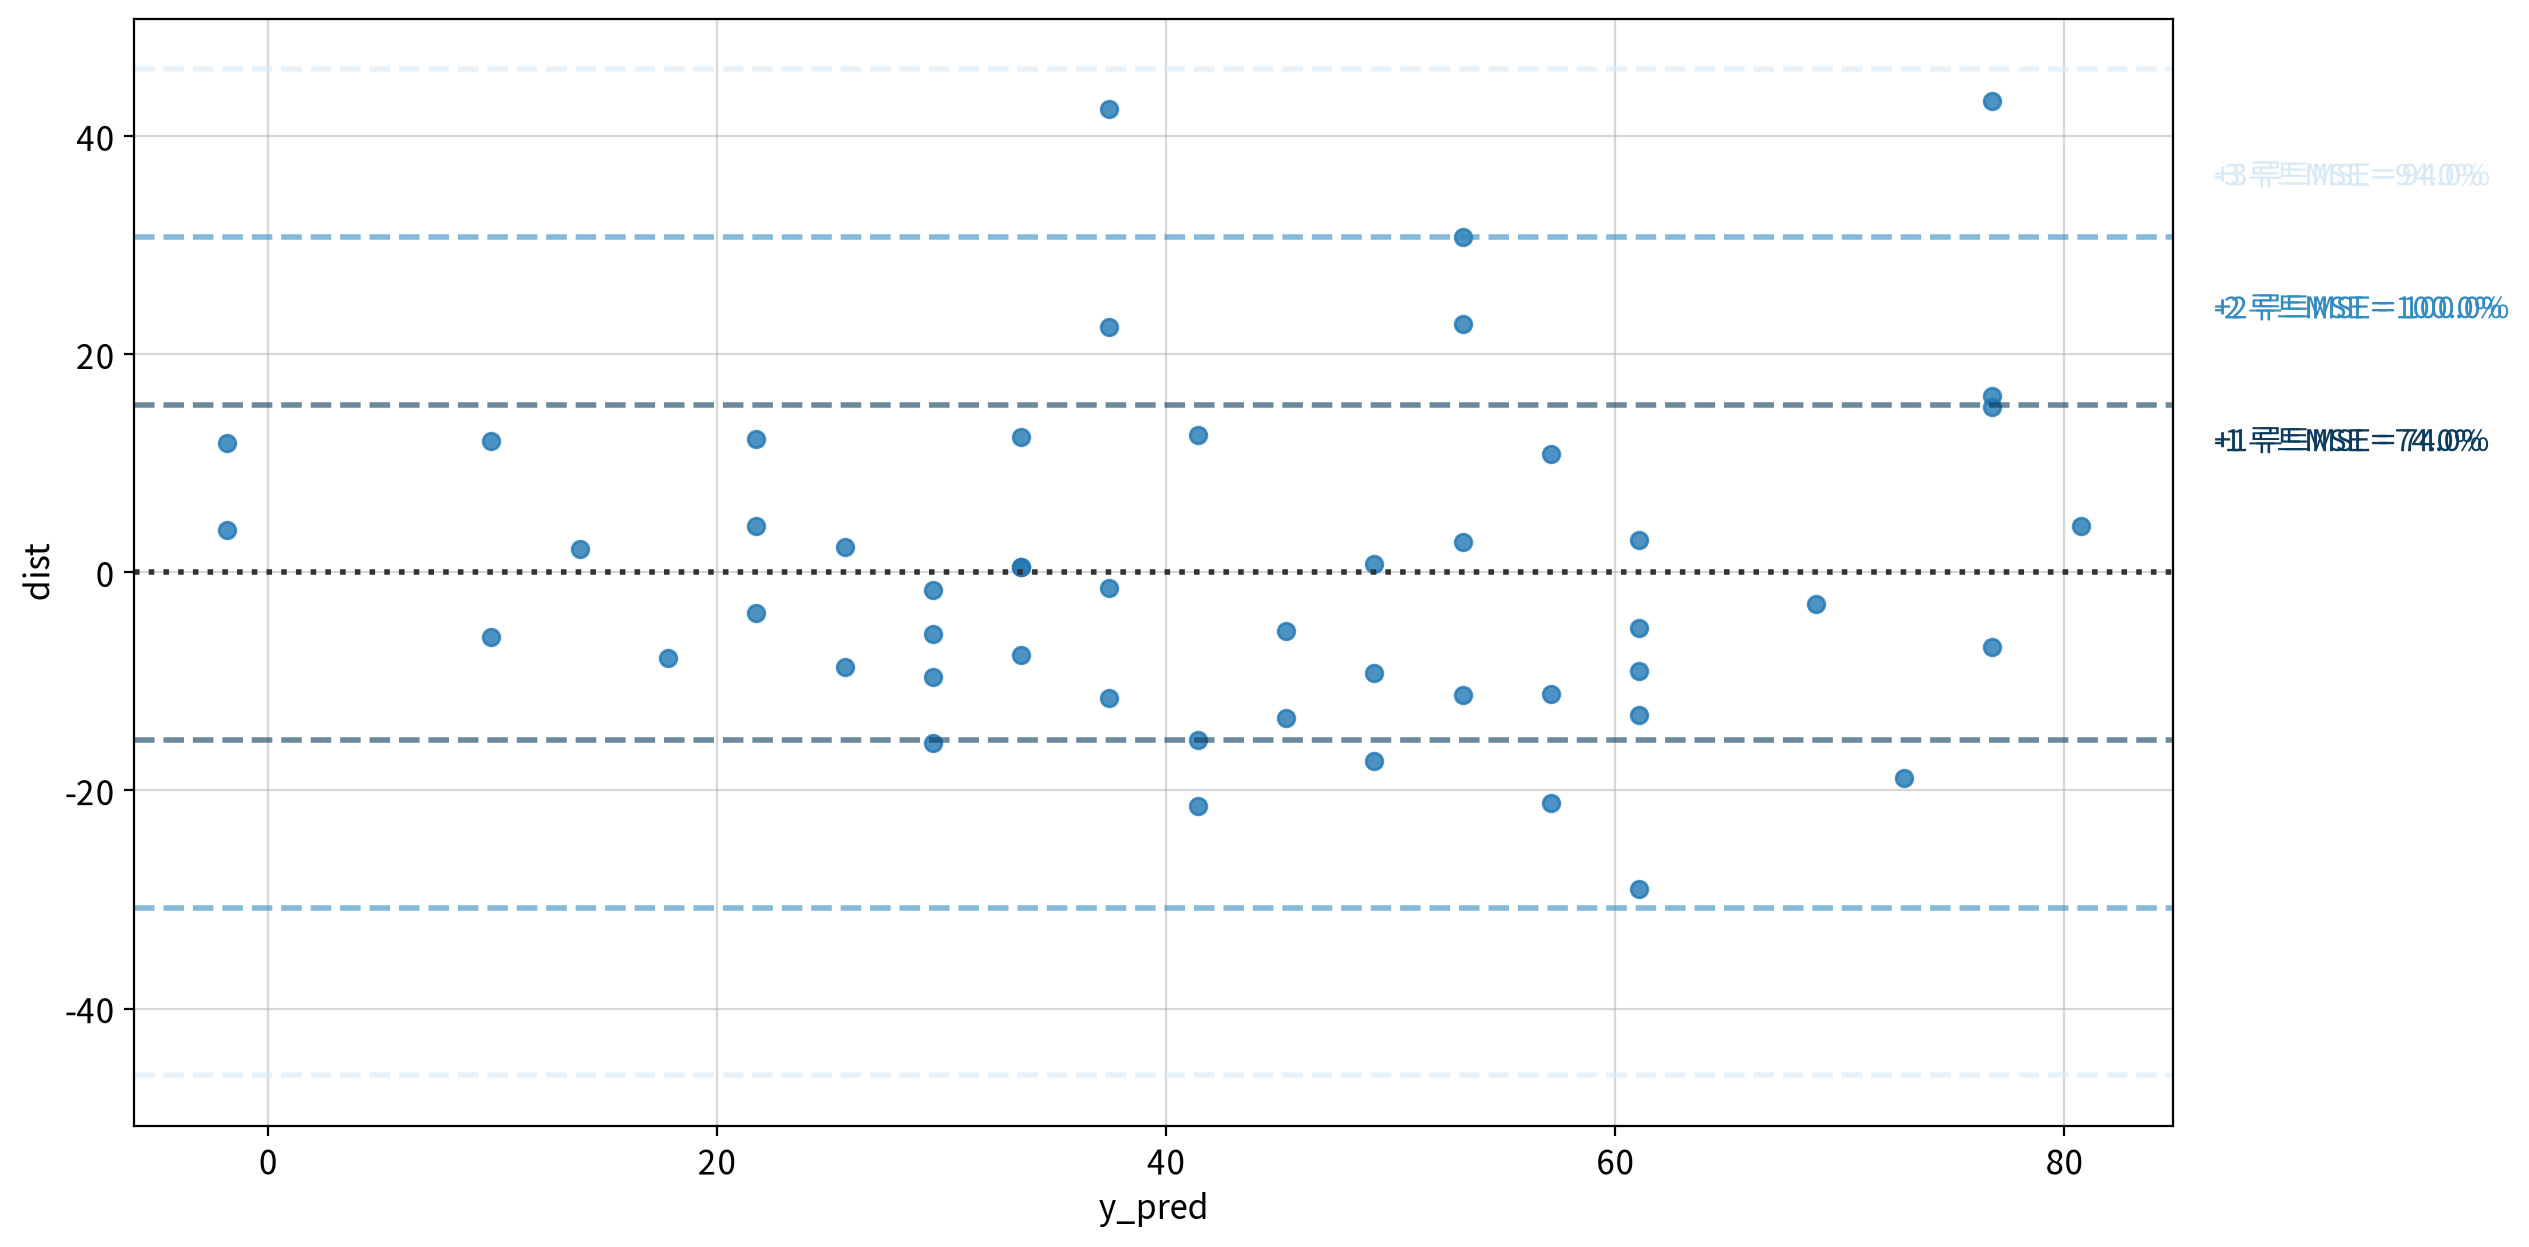

In [49]:
mse_sq = fit.mse_resid      # 잔차 분산 
mse_root = np.sqrt(mse_sq)  # 잔차 분산의 제곱근 
colors = ["#0B3C5D", "#328CC1", "#D9EAF7"]   # 구간별 색상 
xmax = ols_df['y_pred'].max()   # 예측값(y_pred)의 최댓값
ymin = ols_df['y_pred'].min()   # 예측값(y_pred)의 최솟값

fig, ax = my_plot.init()        # 그래프 초기화 

# seaborn 기본 잔차도 
sb.residplot(data=ols_df, x='y_pred', y="dist", ax=ax)

# MSE 3단계 표시 
for i, c in enumerate(colors): # 반복 단계 안에서 : i ->0, 1, 2 / c -> 색상 
    k = i +1                   # 반복 단계 안에서 : 1, 2, 3
    y_pos = k* mse_root        # 반복 단계 안에서 : 1루트MSE, 2루트MSE, 3루트MSE

    # 반복이 진행되는 동안 +-1루트MSE, +-2루트MSE, +-3루트MSE 구간을 점선으로 표시 
    ax.axhline(y=y_pos, color=c, linestyle="--", alpha=0.6)
    ax.axhline(y=-y_pos, color=c, linestyle="--", alpha=0.6)

    # 반복이 진행되는 동안 +-1루트MSE, +-2루트MSE, +-3루트MSE 구간을 점선으로 표시 
    #       x좌표   y좌표          표시문자열 
    ax.text(x=1.02, y=0.5+0.12*k, s=f"+{k} 루트MSE = {mse_r[i]}%", transform=ax.transAxes, 
            ha="left", va="center", fontsize=11, color=c)
    ax.text(x=1.02, y=0.5+0.12*k, s=f"-{k} 루트MSE = {mse_r[i]}%", transform=ax.transAxes, 
            ha="left", va="center", fontsize=11, color=c)
    
my_plot.show()

## #04. 잔차의 정규성 검정 

### 6. 검정 통계량을 통한 정규성 검정 

In [50]:
# 샘플 수에 따라 정규성 검정 선택 
if len(origin) < 30:    # 샘플 수가 30미만이면 Shapiro-Wilk 검정 사용 
    method = "Shapiro-Wilk"
    s, p = shapiro(ols_df['resid'])
else:                   # 샘플 수가 30이상이면 Kolmogorov-Smirnov 검정 사용
    method = "Kolmogorov-Smironov"

    mu = ols_df['resid'].mean()         # 잔차의 평균
    sigma = ols_df['resid'].std(ddof=1) # 잔차의 표준편차 
    z = (ols_df['resid'] - mu) / sigma  # 잔차를 표준화(zscore)하여 정규분포로 변환
    s, p = kstest(z, 'norm')            # 변환된 값이 정규분포(norm)를 따르는지 검정 

print(f"{method} 검정 결과 : statistic={s:.4f}, p-value={p:.4f}")

Kolmogorov-Smironov 검정 결과 : statistic=0.1296, p-value=0.3410


## #05. 잔차의 등분산성 

### 1. 브로이슈 패컨 검정 

In [51]:
# Breusch-Pagan Test 
names = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_test = het_breuschpagan(fit.resid, fit.model.exog)
bp = DataFrame(bp_test, index=names, columns=['value'])

# Breusch - Pagan Test  결과 출력 
# -> 출력 결과에서 F p-value가 0.05보다 작으면 등분산성 가정 위배 
# 나머지 값은 참고하지 않아도 무관하다 
display(bp)

,value
LM Statistic,3.215
LM p-value,0.073
F Statistic,3.298
F p-value,0.076


### 6. 잔차의 독립성 

### 1. Durbin - wason 

In [52]:
dw = durbin_watson(ols_df['resid'])

if 1.5 <= dw <=2.5 : 
    interpretation = "잔차는 독립성을 만족함"
elif dw < 1.5:
    interpretation = "잔차에 양(+)의 자기상관이 존재할 가능성 있음 (독립성 위반)"
else: 
    interpretation = "잔차에 음(-)의 자기상관이 존재할 가능성 있음 (독립성 위반)"

print(f"Durbin-Watson = {dw:.3f} ::: {interpretation}")

Durbin-Watson = 1.676 ::: 잔차는 독립성을 만족함


# 2-2 선형회귀 가정검정의 모듈화 

## #01. 준비작업 

### 1. 라이브러리 참조 

In [53]:
# 라이브러리 기본 참조 
from jussam import load_data
from helpers import *

### 2. 데이터 가져오기 

In [54]:
origin = load_data('cars')
origin.head()

📚 자동차의 속도(speed)에 따른 제동거리(dist) 조사 데이터 (출처: R 기본 데이터)


,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


### 3. 단순선형회귀 

In [55]:
fit = my_ols.fit_model(origin, y='dist')
fit

## #02. 모듈화 기능 확인 

### 1. 선형성 가정 검정 

,statistic,p-value,linearity,result
Ramsey RESET,2.296,0.136,True,귀무가설 채택 -> 선형성 위배 근거 없음


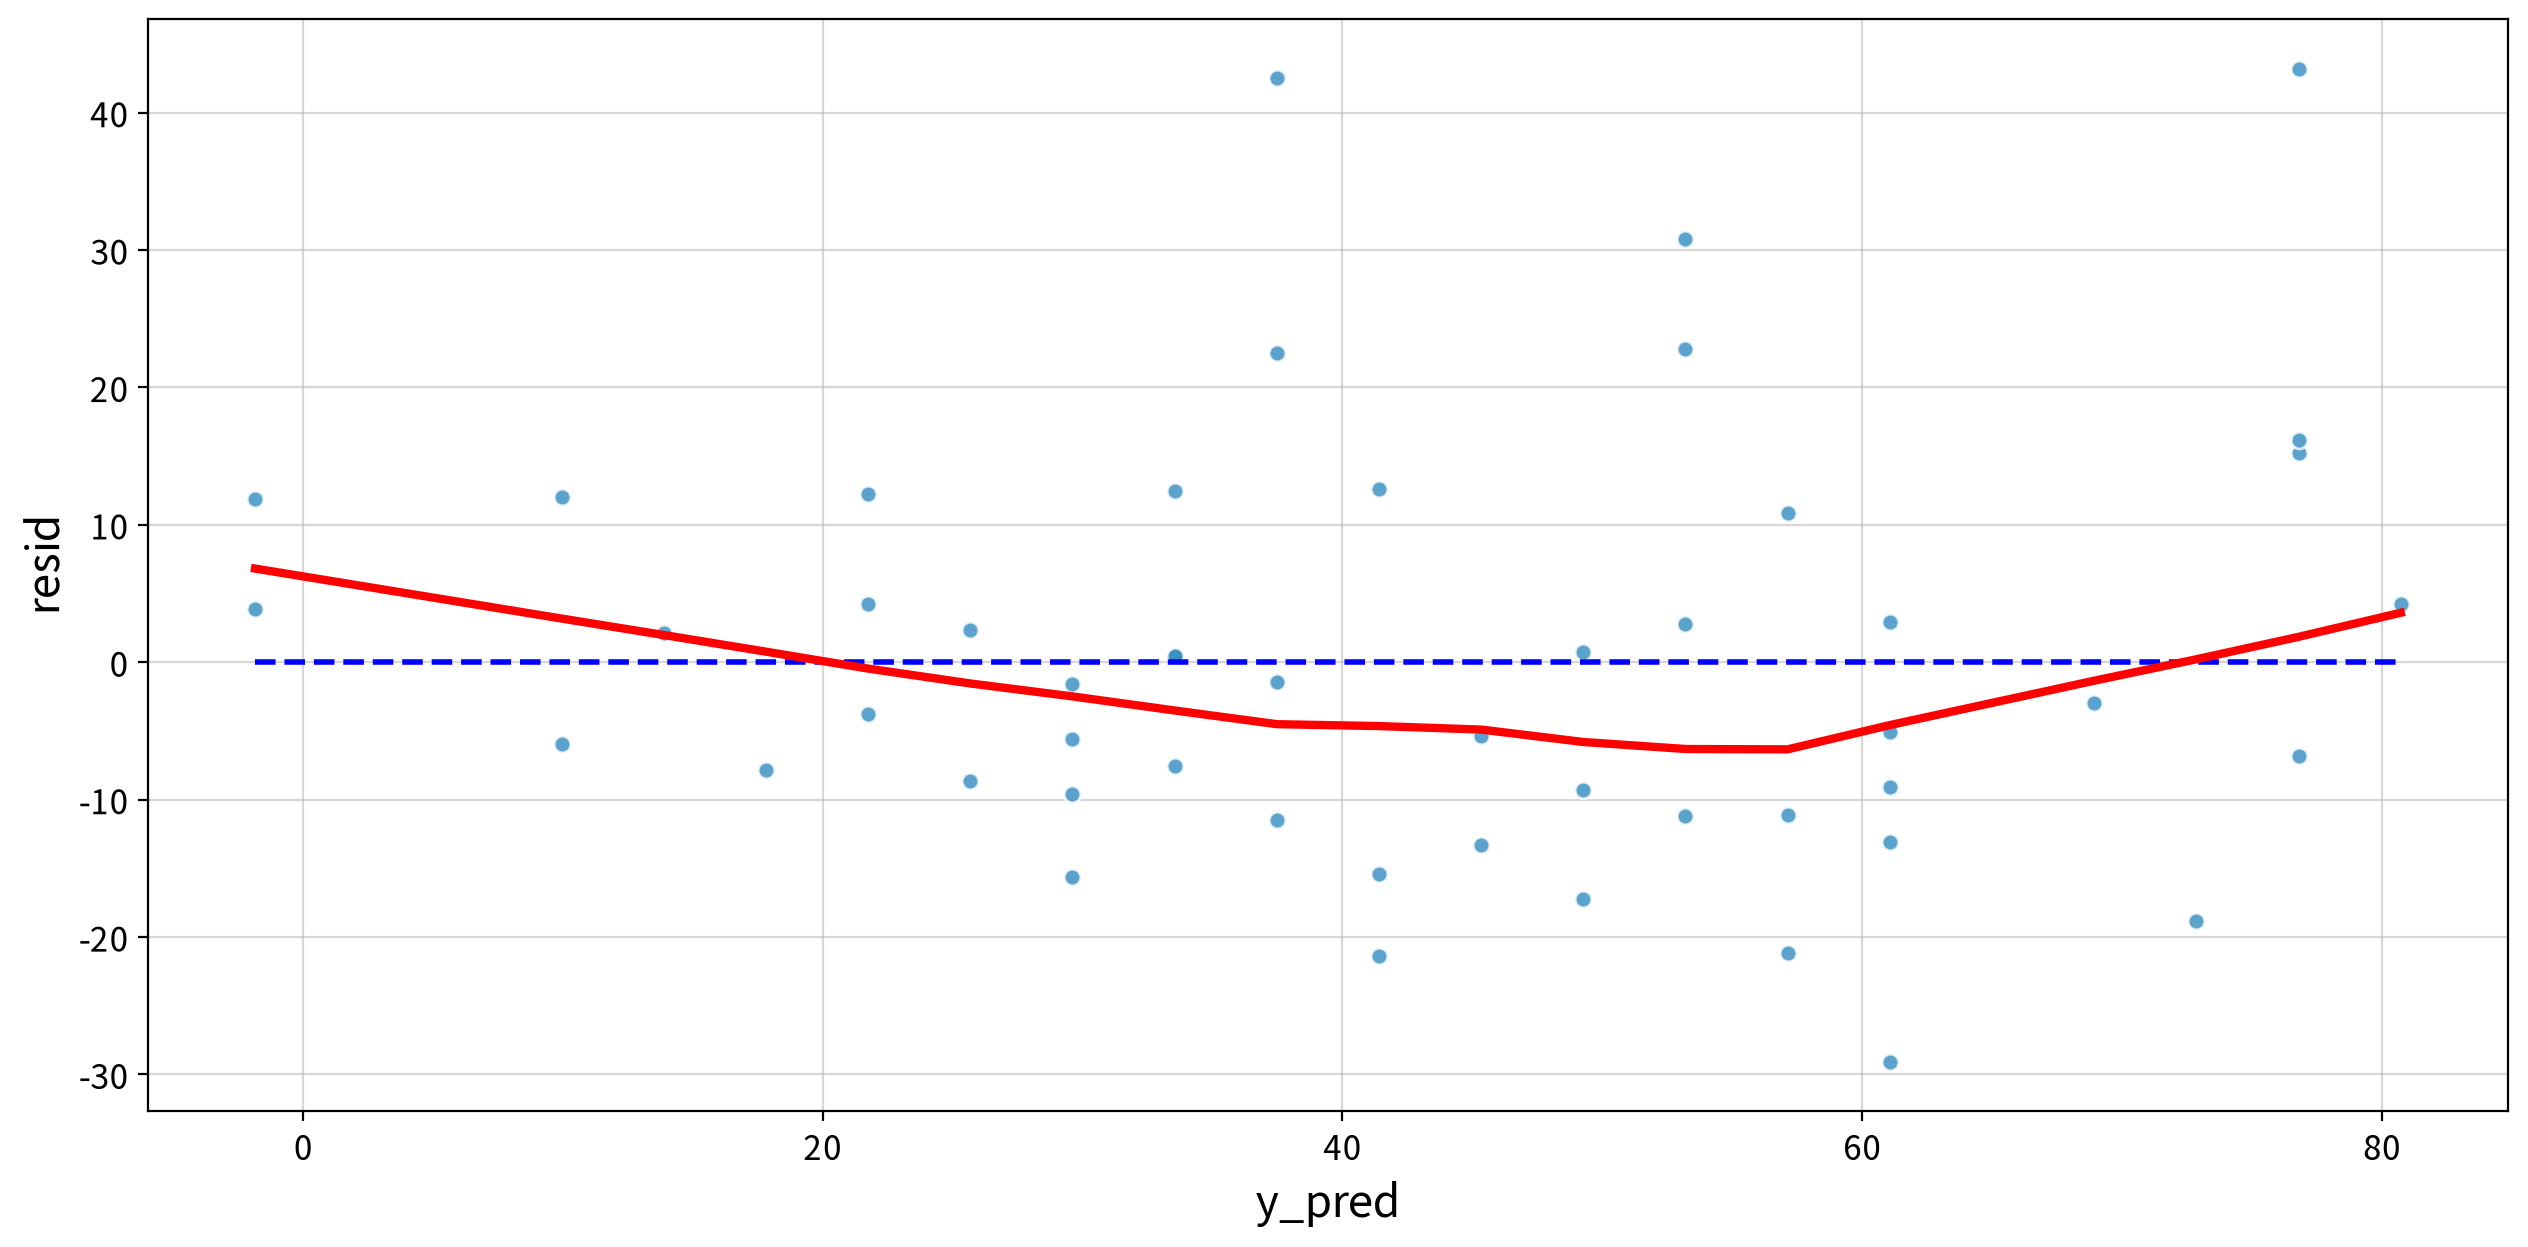

In [56]:
my_ols.test_linear(fit)

### 2. 정규성 가정 점검 

,statistic,p-value,normality,result
kolmogorov-Smirnov,0.130,0.341,True,귀무가설 채택 -> 정규성 만족


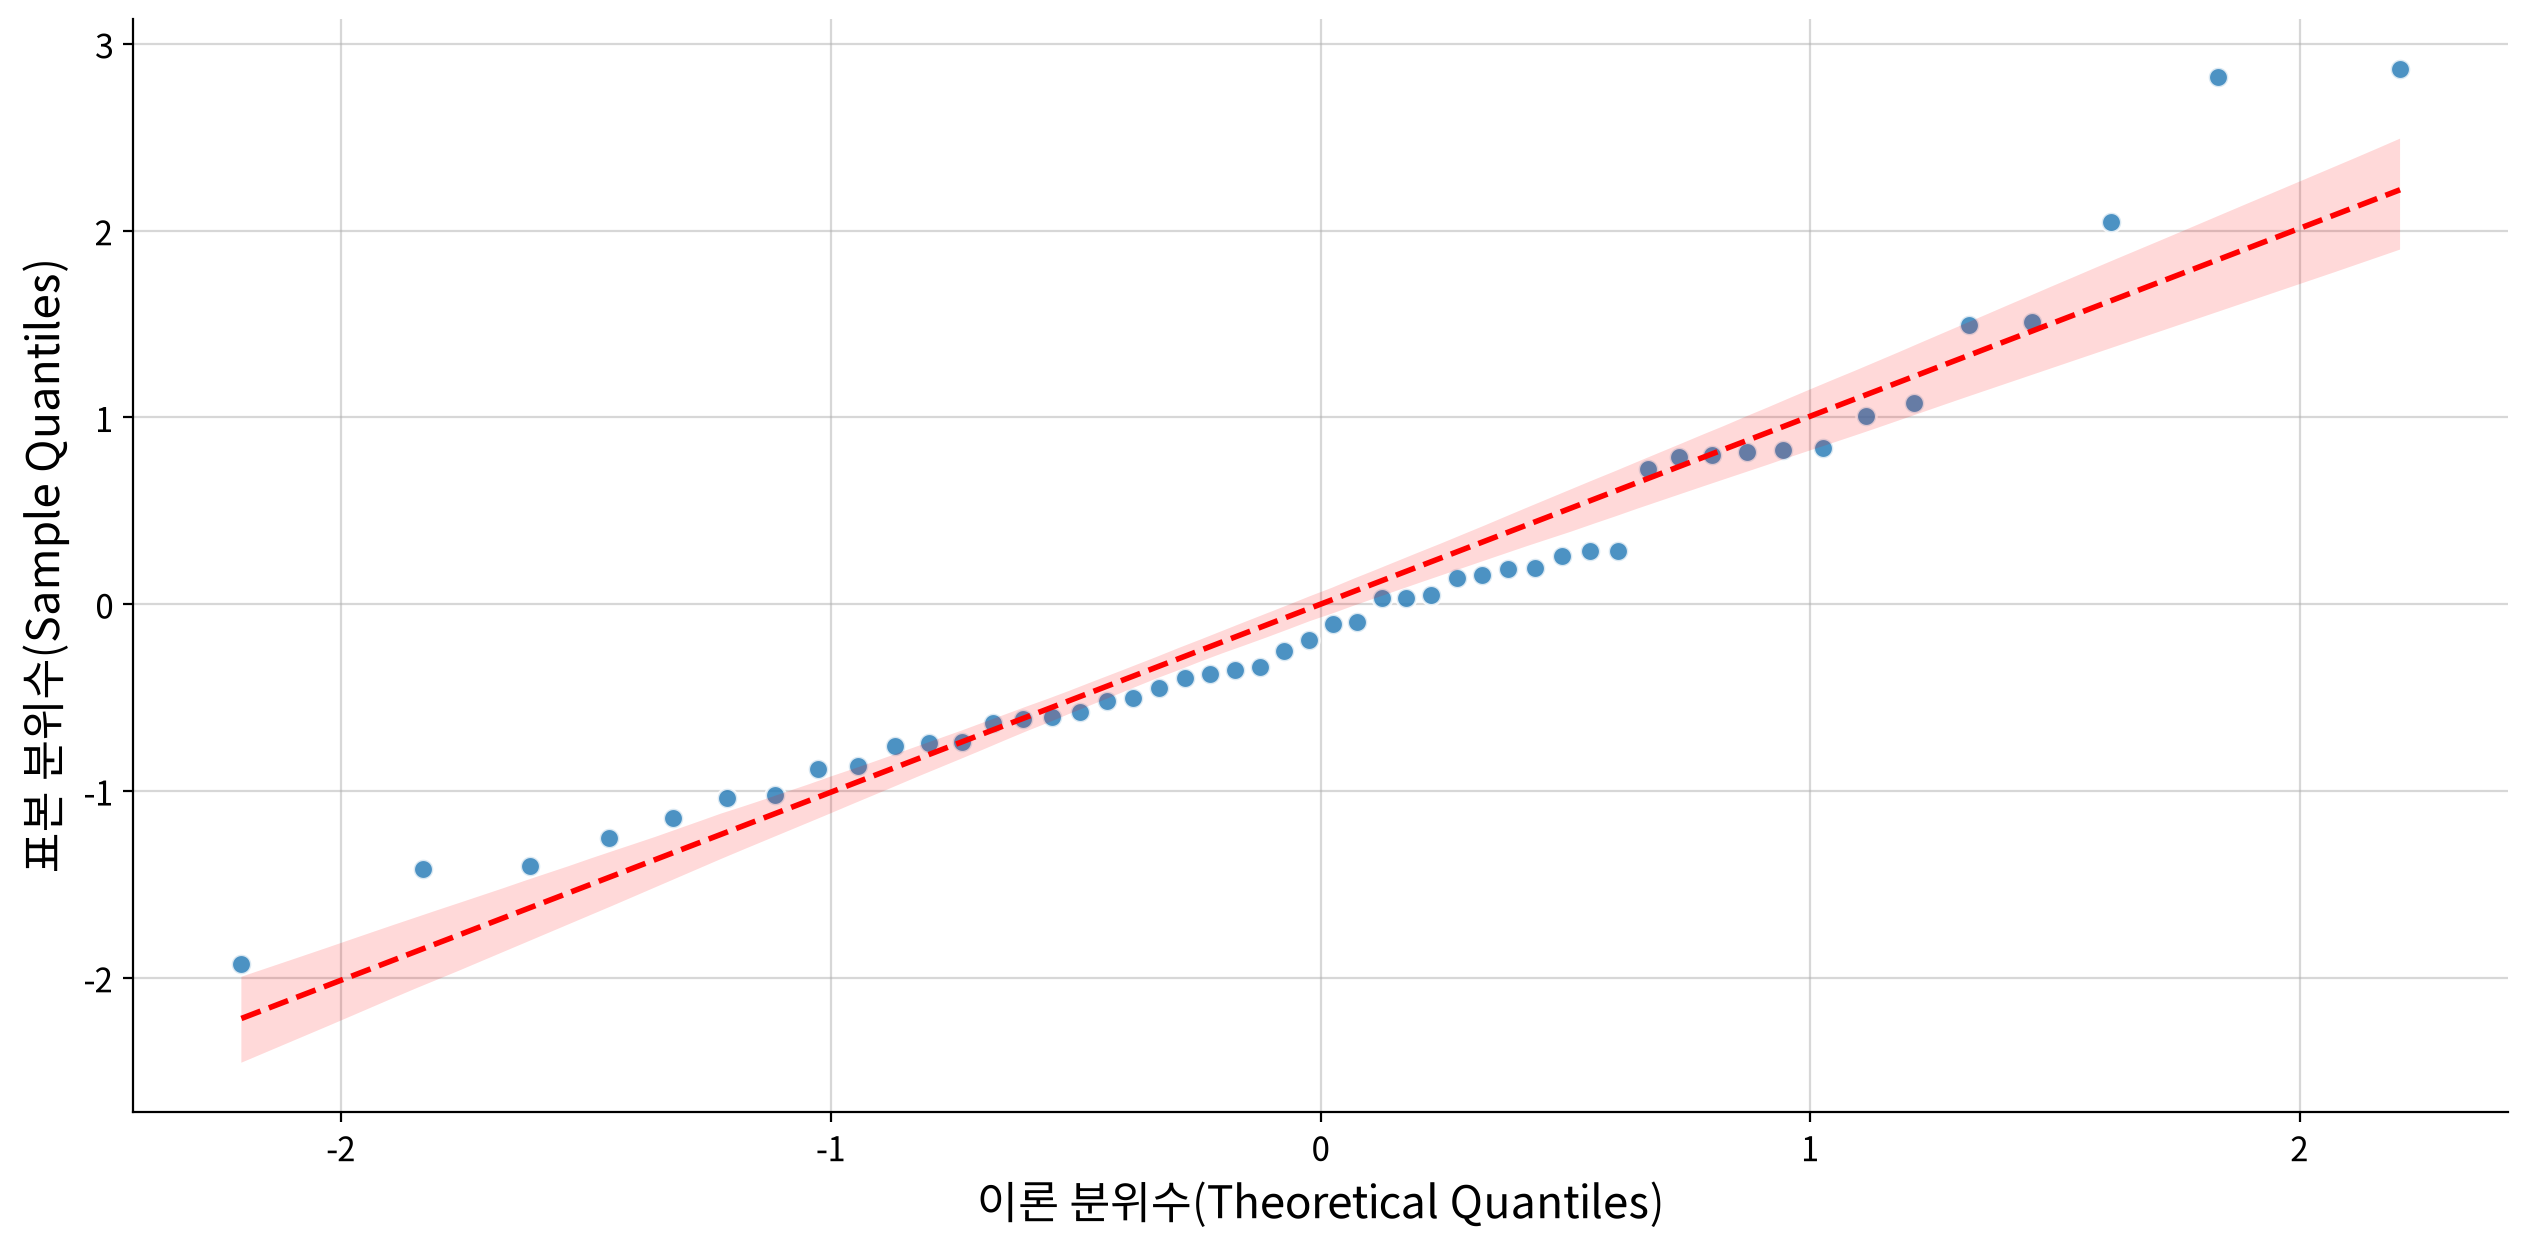

,기대(%),허용범위(%),실제(%),판정
구간,,,,
+-1루트MSE,68.000,55 ~ (hi *100:.0f),74.000,충족
+-2루트MSE,95.000,89 ~ (hi *100:.0f),94.000,충족
+-3루트MSE,99.700,98 ~ (hi *100:.0f),100.000,충족


루트MSE = 15.38 , 구간 규칙 판정: 정규성 부합


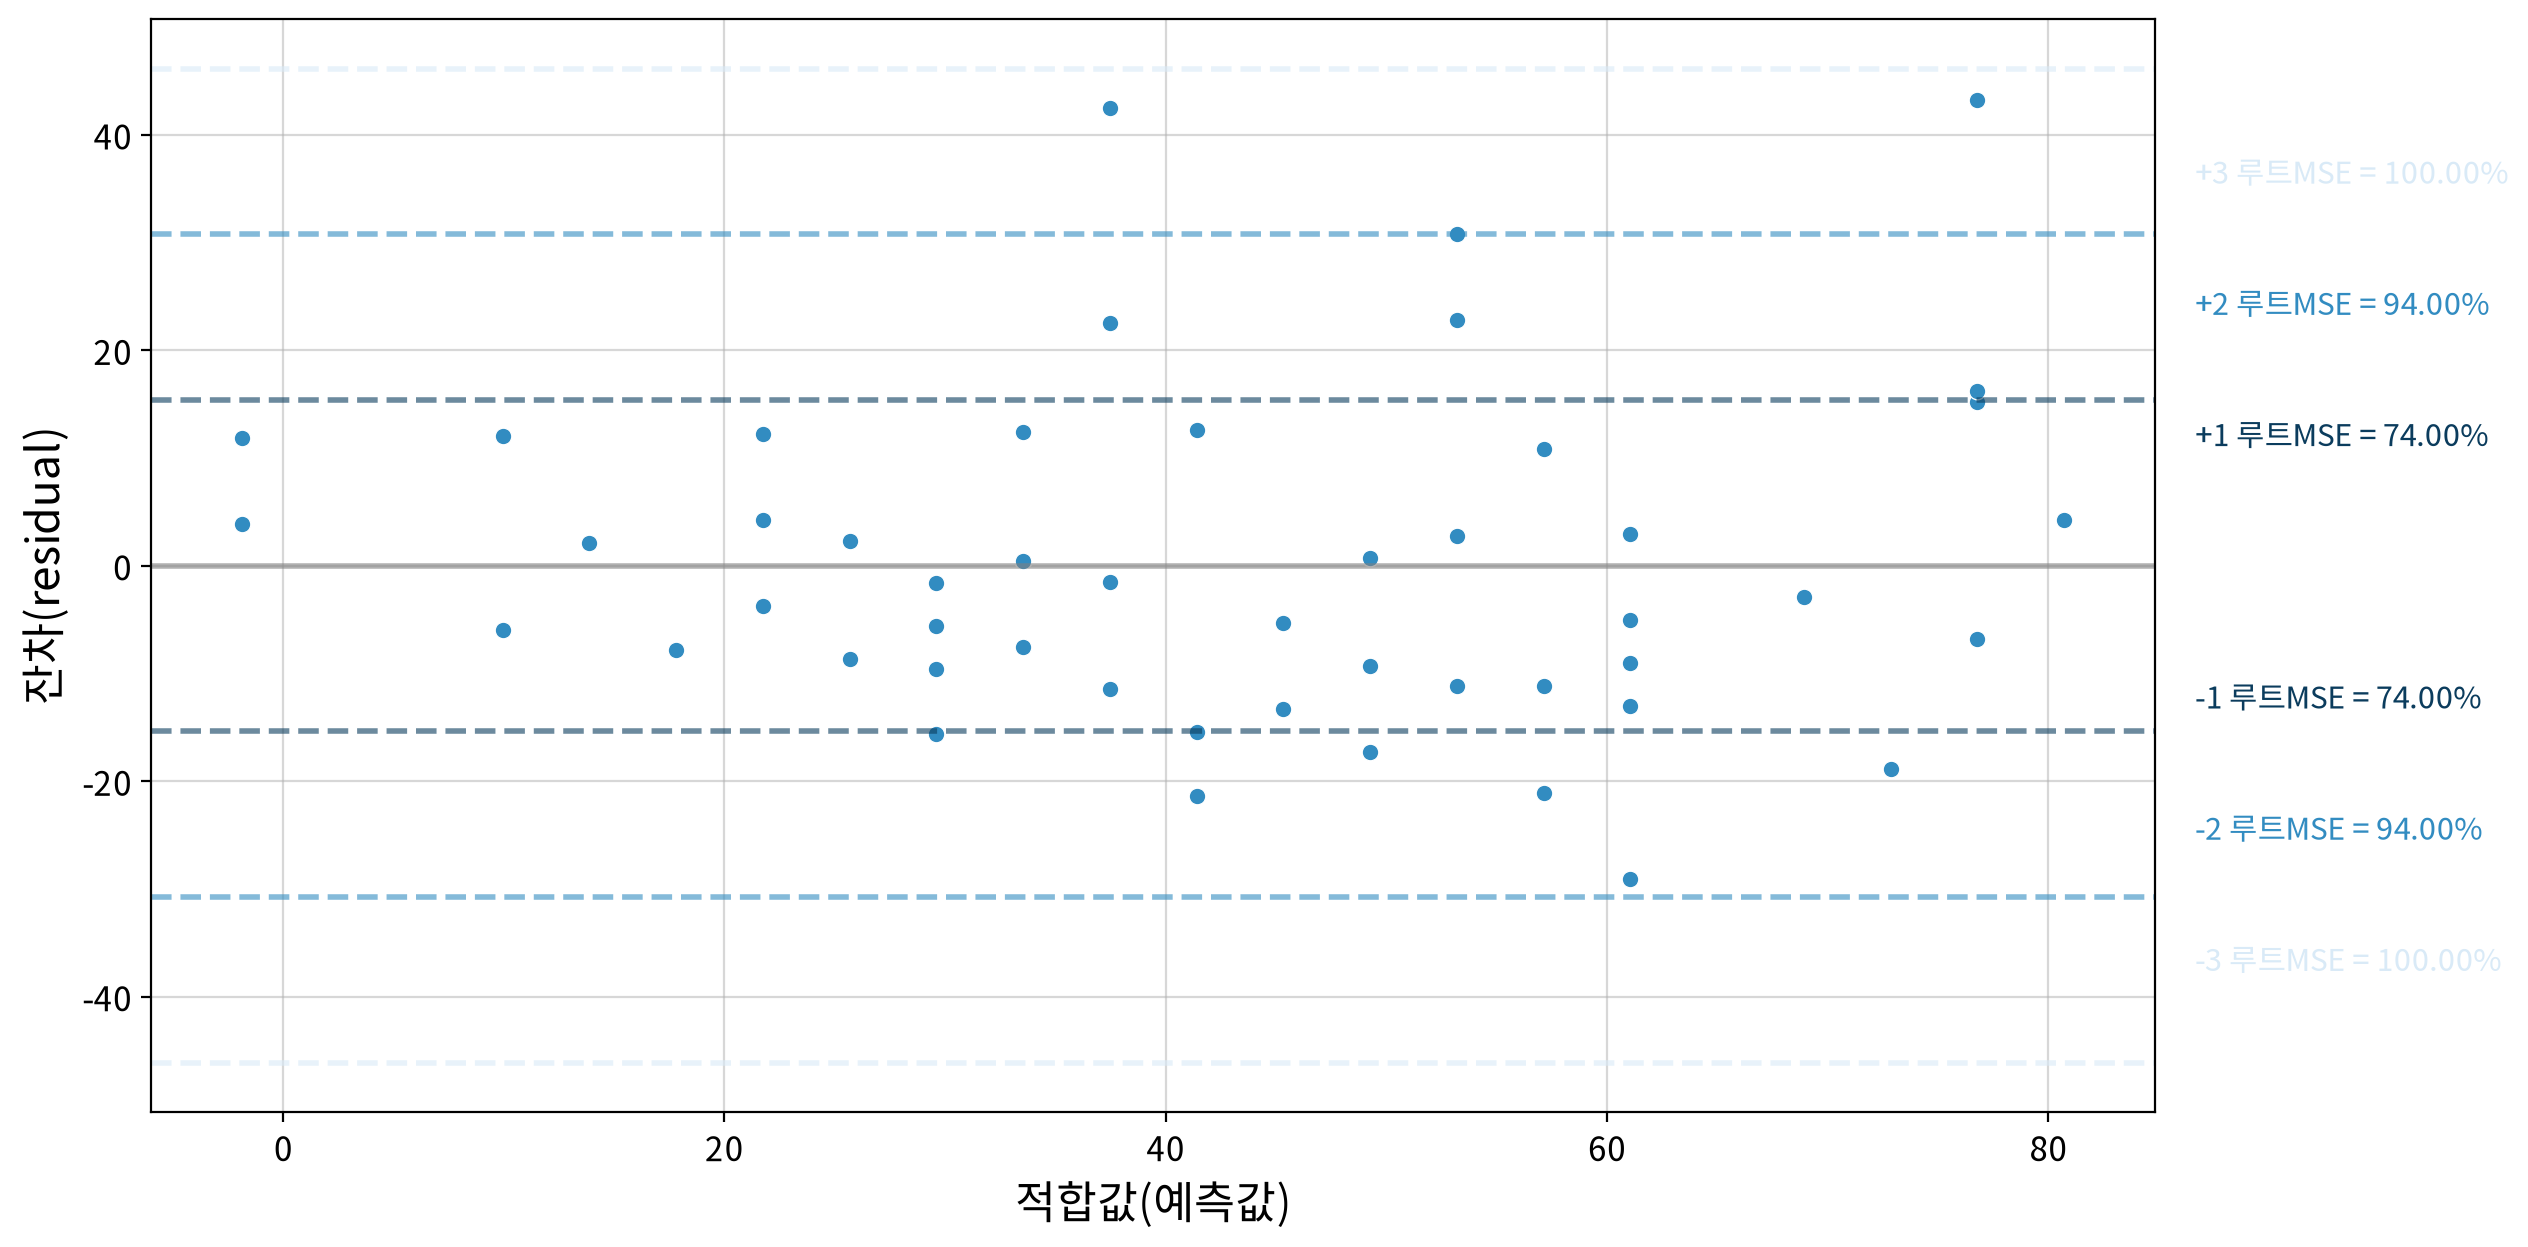

In [57]:
my_ols.test_normal(fit)

### 3. 등분산성 가정 점검 

In [58]:
my_ols.test_equalvar(fit)

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,3.215,0.073,3.298,0.076,True,귀무가설 채택 -> 등분산성 만족


### 4. 독립성 가정 점검 

In [59]:
my_ols.test_independent(fit)

,statistic,independence,result
Durbin-Watson,1.676,True,독립성 만족


## #01. 연습문제 

In [60]:
origin = load_data("father-son")
origin.head()

📚 아버지와 아들의 키를 조사한 데이터 (출처: https://www.kaggle.com/datasets/aungdev/pearson-dataset-heights-of-fathers-and-their-sons)


,fheight,sheight
0,65.049,59.778
1,63.251,63.214
2,64.955,63.342
3,65.752,62.792
4,61.137,64.281


In [61]:
# 단순선형회귀 모형으로부터 잔차와 적합값 추출 
fit = my_ols.fit_model(origin, y='sheight')
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                sheight   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     361.2
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           1.12e-69
Time:                        18:05:43   Log-Likelihood:                -2488.7
No. Observations:                1078   AIC:                             4981.
Df Residuals:                    1076   BIC:                             4991.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.8866      1.832     18.493      0.000      30.291      37.482
fheight        0.5141      0.027     19.006      0.000       0.461       0.567
==============================================================================
Omnibus:                       17.605   Durbin-Watson:                   0.767
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               30.849
Skew:                          -0.051   Prob(JB):                     2.00e-07
Kurtosis:                       3.822   Cond. No.                     1.67e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.67e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [62]:
# 잔차(residual)와 적합값(fitted value) 추출 - 이후 모든 가정 검정의 '증거'가 된다.
resid = fit.resid # 잔차 e = 실제값 - 예측값 
fitted = fit.fittedvalues # 적합값(예측값) y헷

# 적합값 , 잔차를 원본 옆에 나란히 정리 
evidence = origin.copy()
evidence["적합값"] = fitted
evidence["잔차"] = resid 

print(f"표본 수 n = {int(fit.nobs)}")
print(f"잔차 평균 ~~ {resid.mean():.2e} (0에 수렴 - OLS의 성질)")
print(f"잔차 표준편차 루트MSE ~~ {fit.mse_resid ** 0.5:.4f}")
evidence.head()

표본 수 n = 1078
잔차 평균 ~~ -1.81e-13 (0에 수렴 - OLS의 성질)
잔차 표준편차 루트MSE ~~ 2.4366


,fheight,sheight,적합값,잔차
0,65.049,59.778,67.328,-7.549
1,63.251,63.214,66.403,-3.189
2,64.955,63.342,67.280,-3.937
3,65.752,62.792,67.690,-4.897
4,61.137,64.281,65.317,-1.036


,statistic,p-value,linearity,result
Ramsey RESET,0.032,0.859,True,귀무가설 채택 -> 선형성 위배 근거 없음


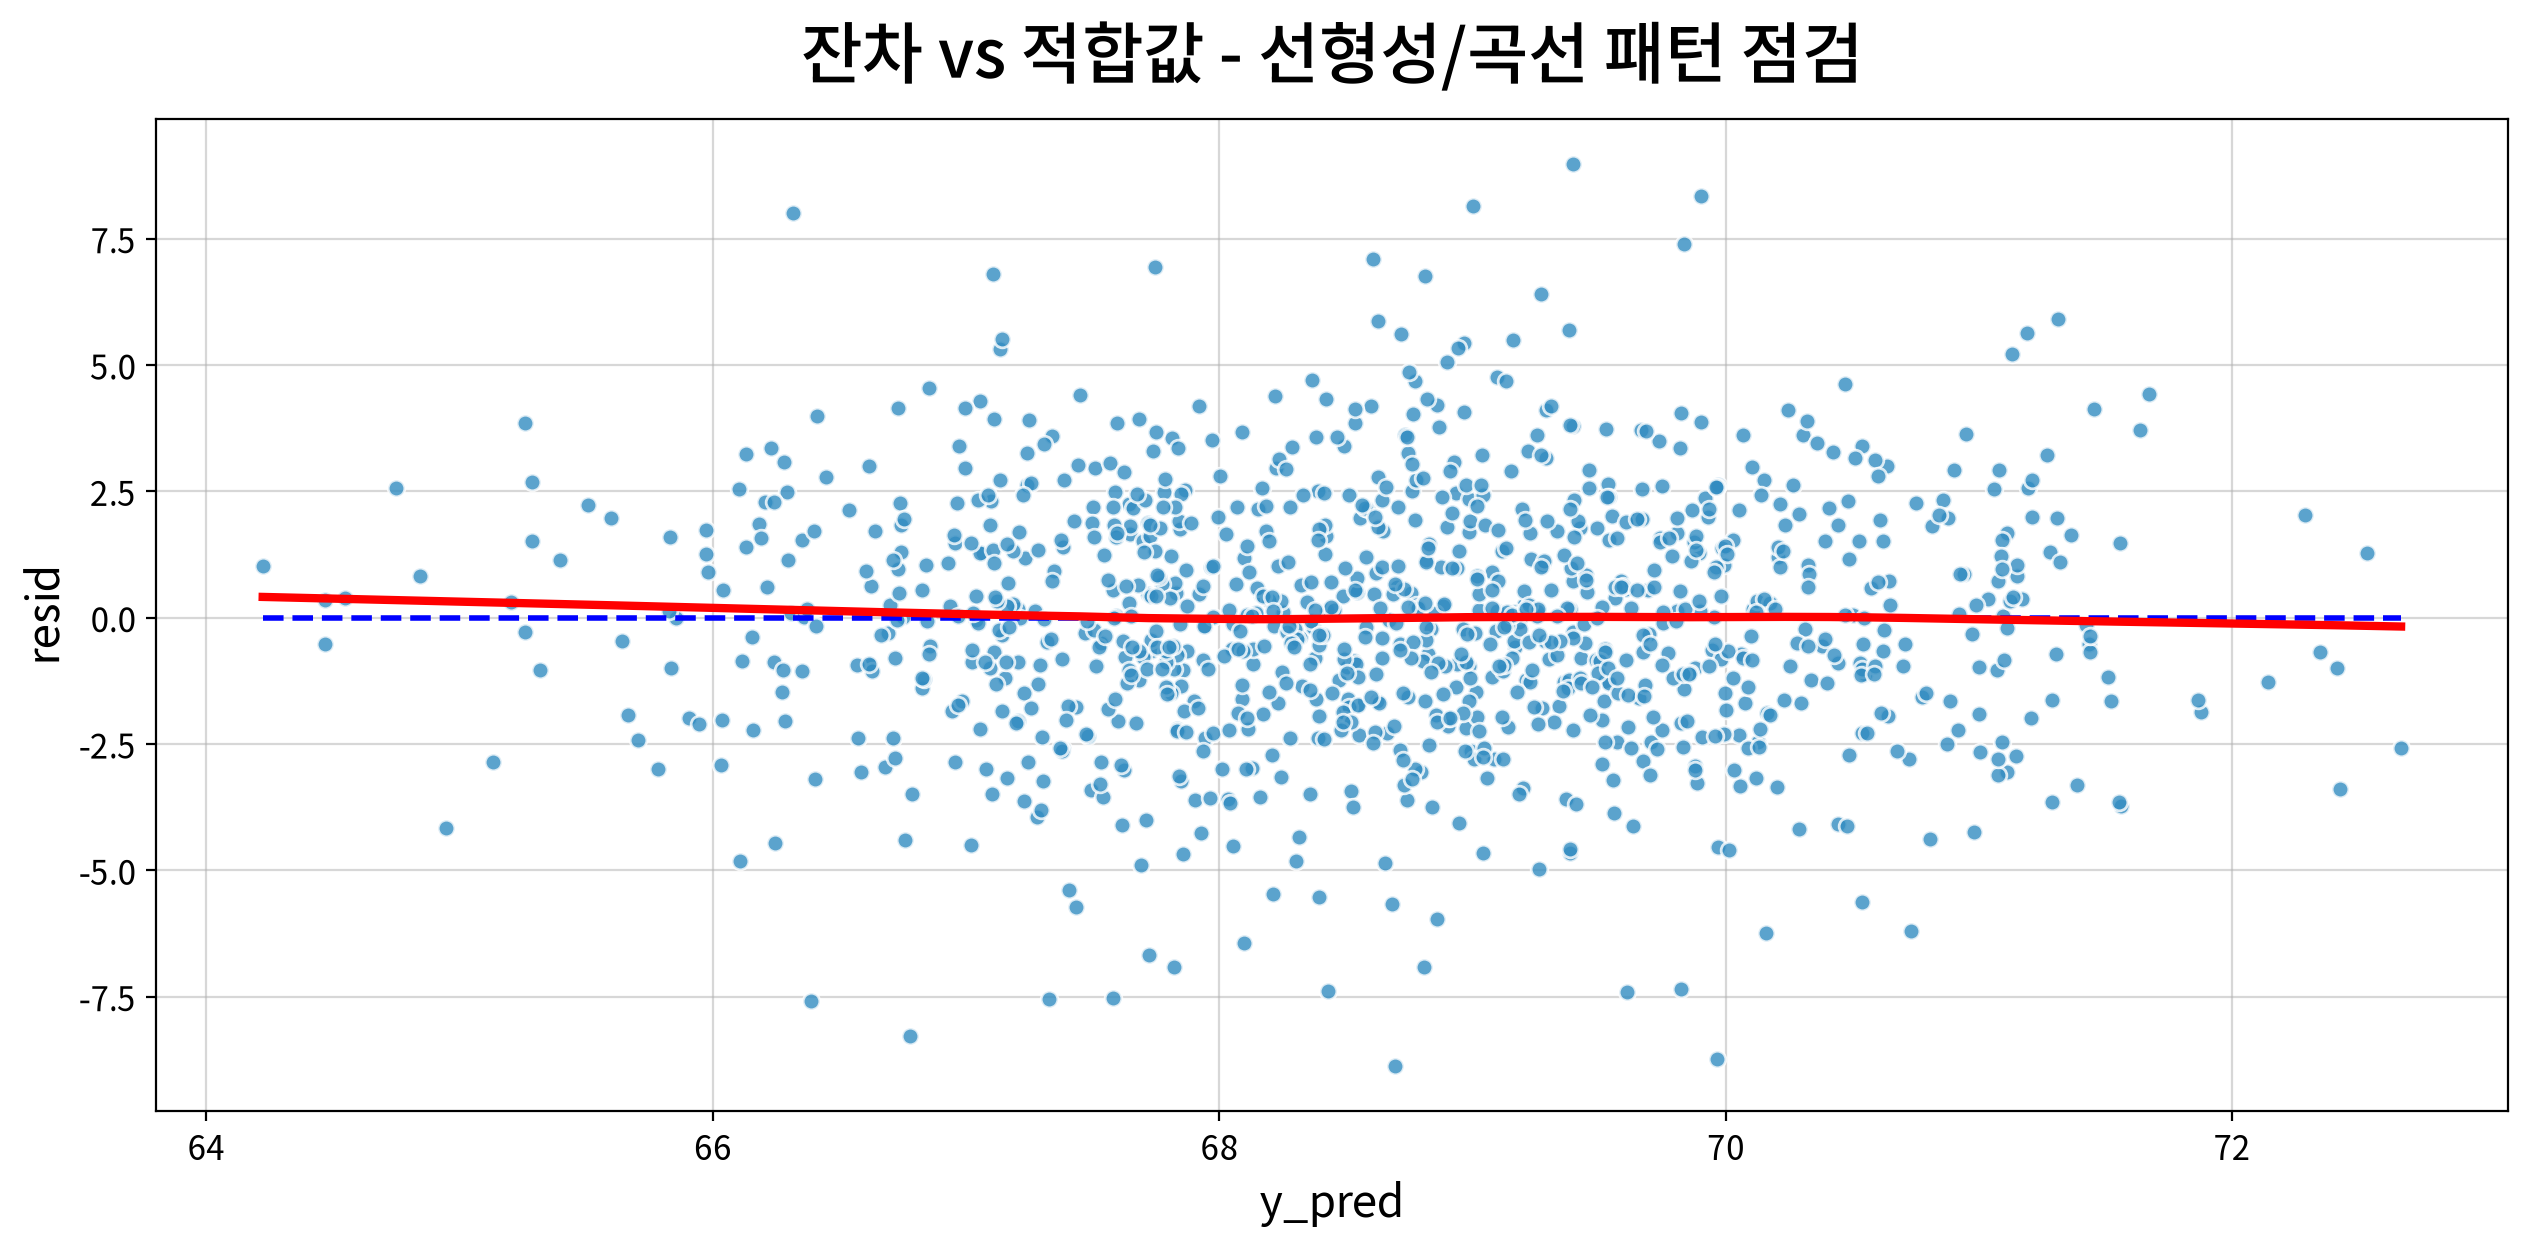

In [63]:
my_ols.test_linear(fit, title="잔차 vs 적합값 - 선형성/곡선 패턴 점검")

,statistic,p-value,normality,result
kolmogorov-Smirnov,0.022,0.667,True,귀무가설 채택 -> 정규성 만족


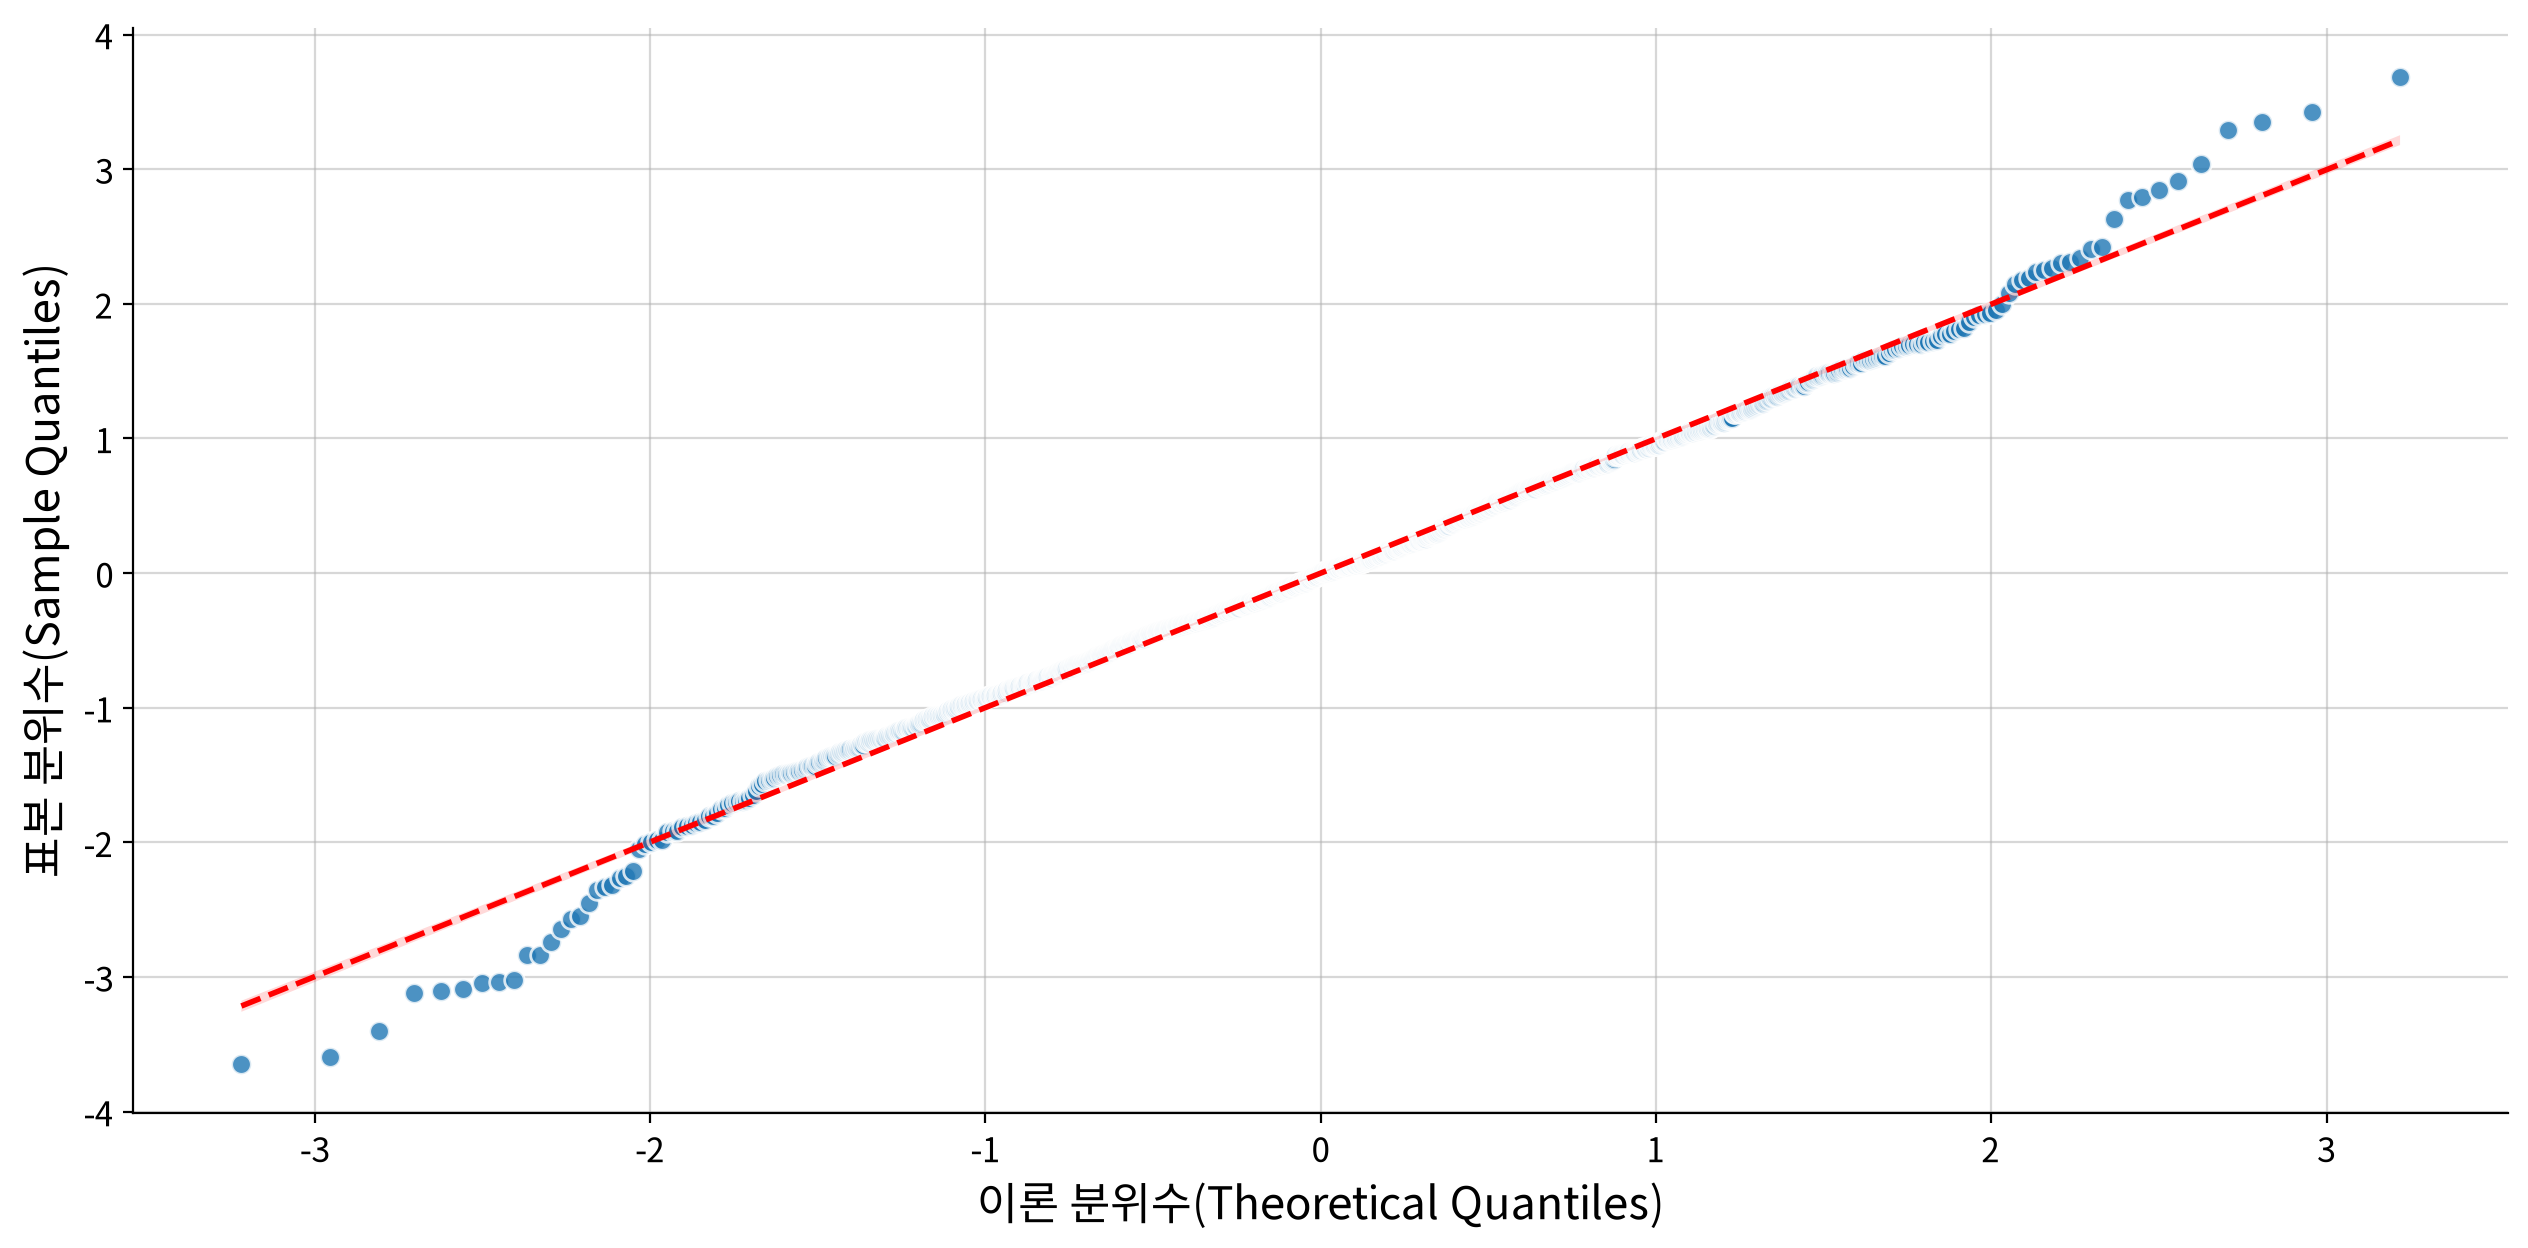

,기대(%),허용범위(%),실제(%),판정
구간,,,,
+-1루트MSE,68.000,65 ~ (hi *100:.0f),71.430,위배
+-2루트MSE,95.000,94 ~ (hi *100:.0f),95.730,충족
+-3루트MSE,99.700,99 ~ (hi *100:.0f),98.700,위배


루트MSE = 2.44 , 구간 규칙 판정: 정규성 위배


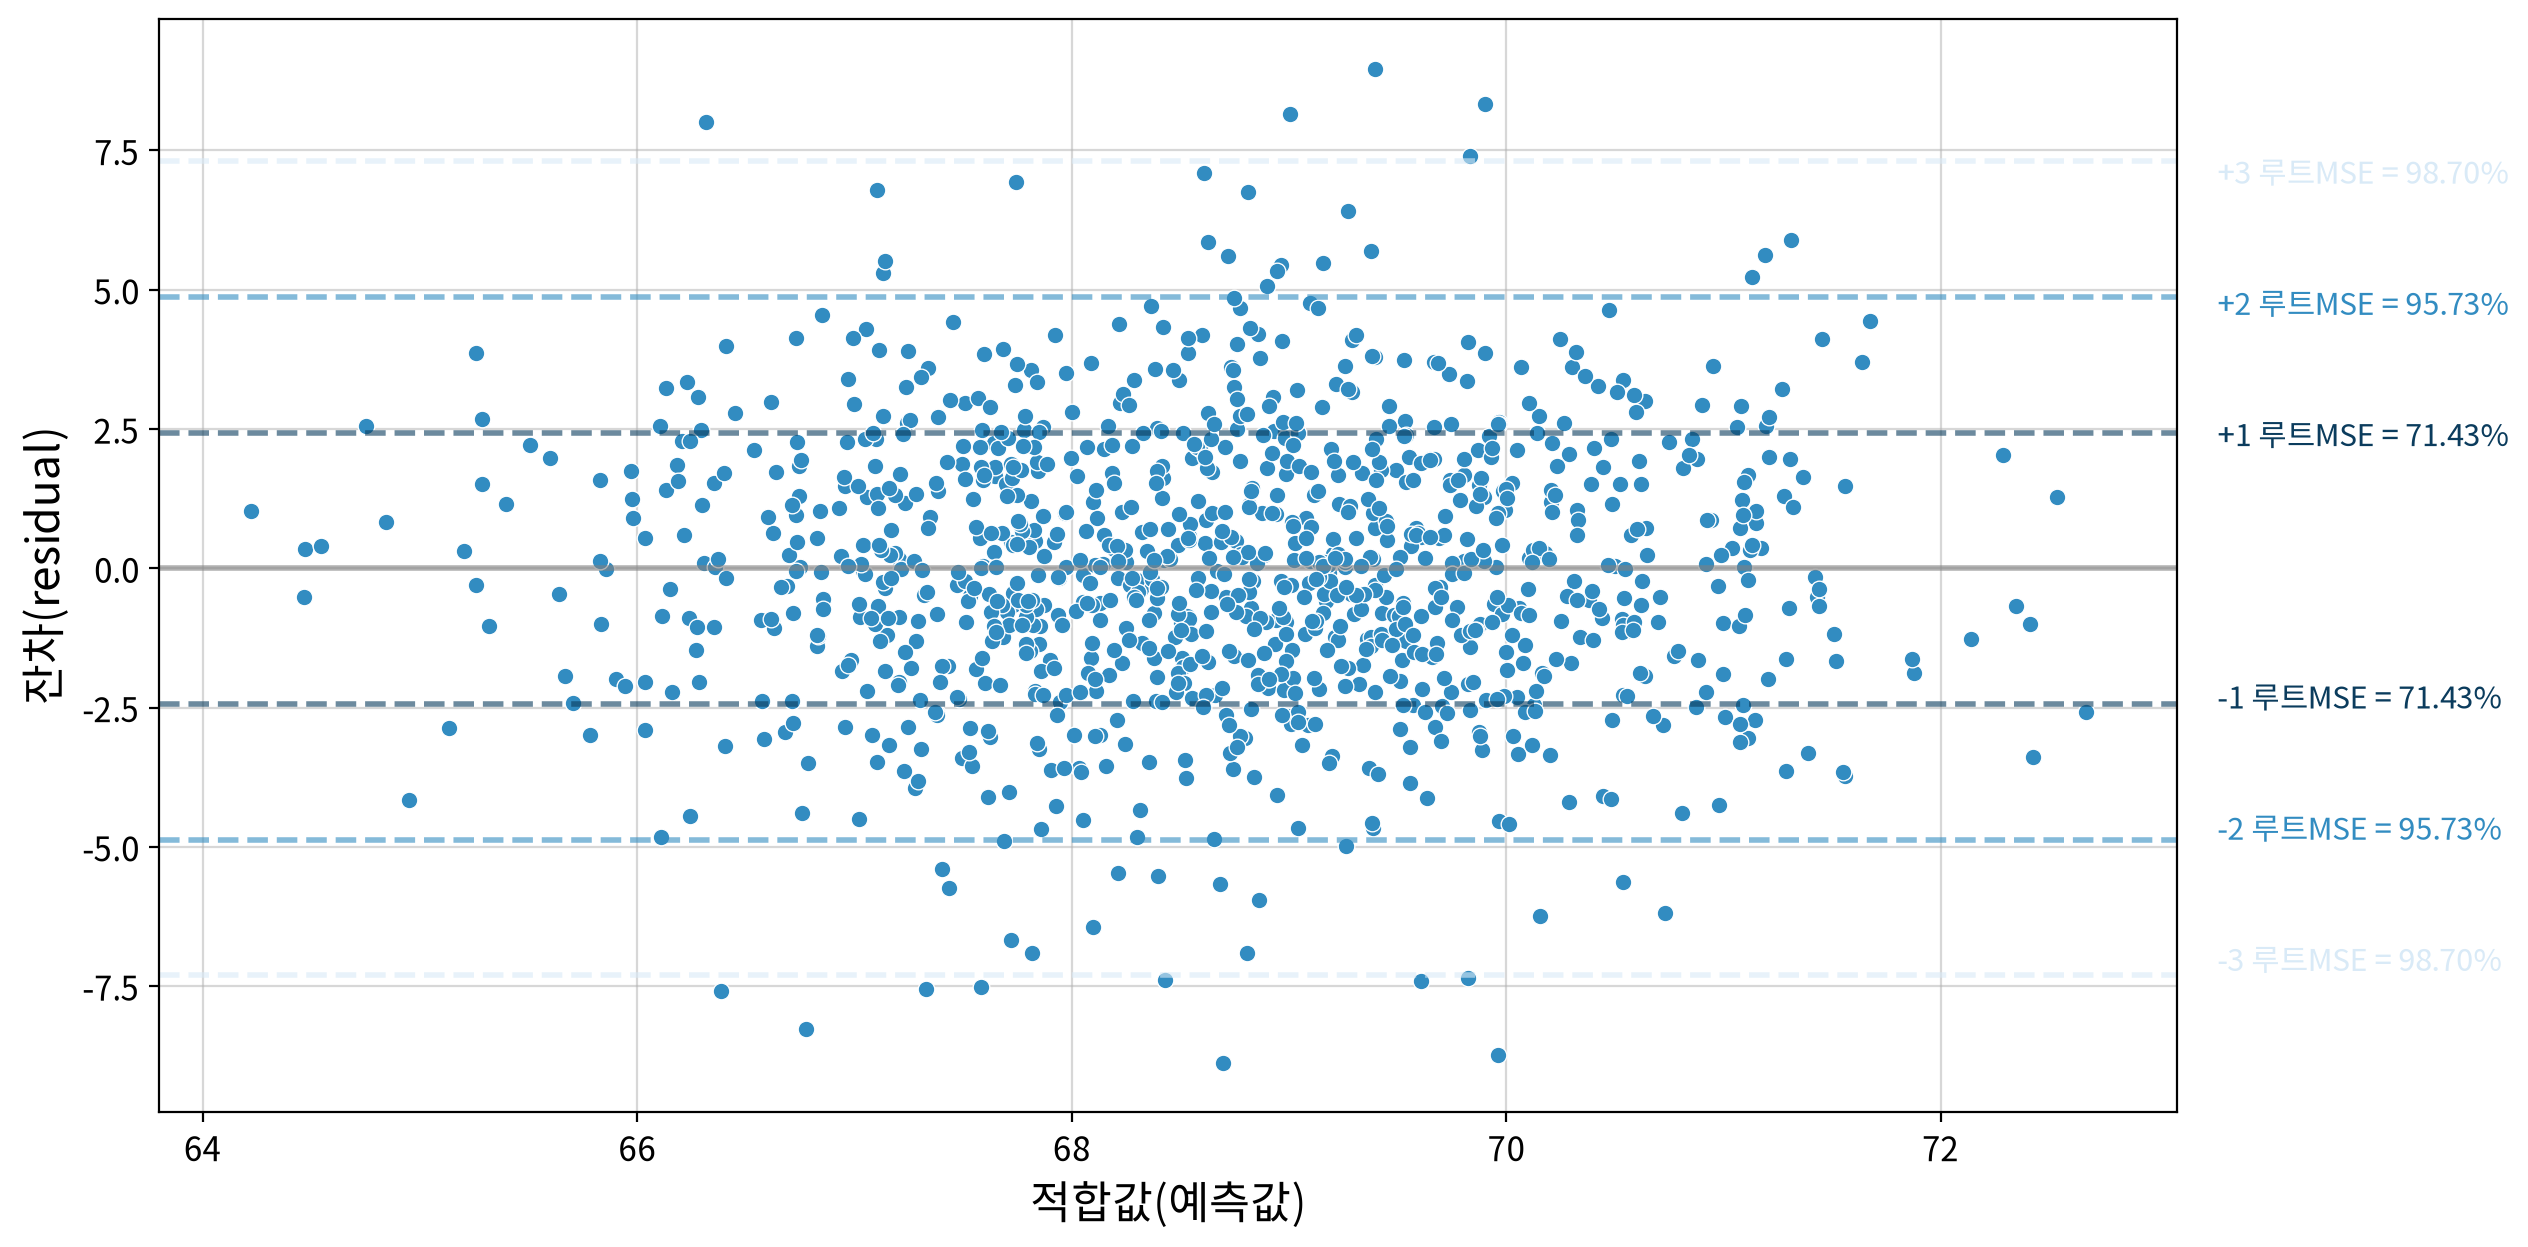

In [64]:
my_ols.test_normal(fit)

In [65]:
my_ols.test_equalvar(fit)

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,0.003,0.960,0.003,0.960,True,귀무가설 채택 -> 등분산성 만족


In [66]:
my_ols.test_independent(fit)

,statistic,independence,result
Durbin-Watson,0.766,False,독립성 위반 (양(+)의 자기상관)
